Hai a disposizione un file data.csv contenente dati mensili di traffico aereo con due colonne:

date: data in formato YYYY-MM (mese/anno)
passengers: numero di passeggeri per quel mese
Costruisci un modello di regressione polinomiale che approssima l’andamento del numero di passeggeri nel tempo.

Carica il dataset.
Convertilo in un formato numerico utilizzando una colonna mese_numerico che conti i mesi a partire da gennaio 1949.
Applica una regressione polinomiale (grado a tua scelta).
Calcola l’RMSE tra i valori reali e quelli predetti.
Visualizza i dati reali e la curva stimata con Plotly.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plotly

In [28]:
df=pd.read_csv("data.csv")  #carico
df=df.dropna()  #pulisco dagli na
print(df.head())  #visualizzo

df["date"]=pd.to_datetime(df["date"])  #converto in formato data
df=df.sort_values("date")  #ordino secondo data
df["mese_numerico"]=(df["date"].dt.year - 1949)*12 + (df["date"].dt.month-1)
print(df.head())

X=df[["mese_numerico"]]  #definisco per la regressione
Y=df["passengers"]

      date  passengers
0  1949-01       112.0
1  1949-02       118.0
2  1949-03       132.0
3  1949-04       129.0
4  1949-05       121.0
        date  passengers  mese_numerico
0 1949-01-01       112.0              0
1 1949-02-01       118.0              1
2 1949-03-01       132.0              2
3 1949-04-01       129.0              3
4 1949-05-01       121.0              4


41.13832291165036


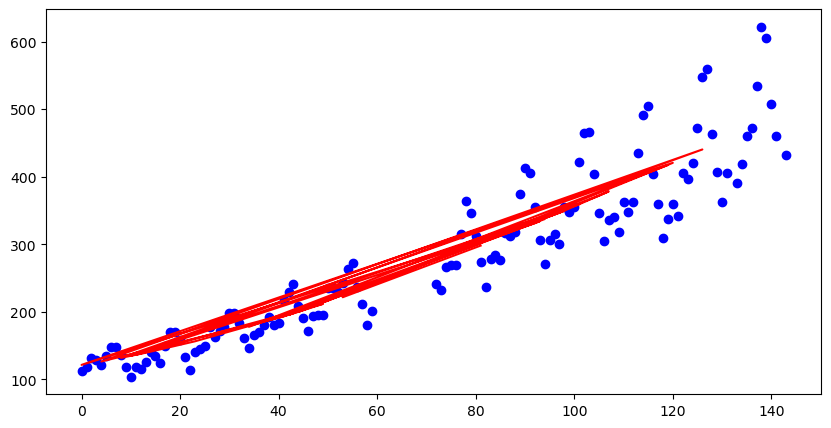

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)  #20% test, il resto training
modello = make_pipeline(PolynomialFeatures(3), LinearRegression())  #costruisco un modello con un polinomio di grado 3
modello.fit(X_train, Y_train)  #fitto il modello
Y_lineare=modello.predict(X_test)  #faccio il predict segueno un modello lineare

rmse_lineare = root_mean_squared_error(Y_test, Y_lineare)  #calcolo l'RMSE tra dati reali e predetti
print(rmse_lineare)  #visualizzo

'''
plt.figure(figsize=(10, 5))
plt.scatter(X, Y, label="Dati reali", color="blue")
plt.plot(X_test, Y_lineare, color="red")
'''